## Modelowanie produkcji OZE
- Budowa modelu predykcji generacji energii słonecznej i wiatrowej
- Krzywa mocy turbiny wiatrowej
- Model PV: irradiancja + moc zainstalowana
- Weryfikacja modelu – błąd, RMSE, MAE
- Wpływ prognoz pogody na modele

Efekty lekcji:
(Potrafię…)
- Zbudować prosty model produkcji energii z instalacji fotowoltaicznej na podstawie danych o irradiancji, temperaturze i mocy zainstalowanej
- Skonstruować model produkcji energii z turbiny wiatrowej, wykorzystując dane o prędkości wiatru oraz charakterystykę krzywej mocy
- Przeprowadzić walidację modeli produkcji OZE, obliczając podstawowe miary błędu (np. MAE, RMSE), i zinterpretować ich dokładność w kontekście operacyjnym

In [1]:
!pip install openmeteo-requests
!pip install retry-requests
!pip install requests-cache
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.7/786.7 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.9 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Setup Open-Meteo session
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

cities = [
    {"name": "Warszawa", "lat": 52.2297, "lon": 21.0122},
    {"name": "Kraków",   "lat": 50.0647, "lon": 19.9450},
    {"name": "Gdańsk",   "lat": 54.3520, "lon": 18.6466},
]

url = r"https://archive-api.open-meteo.com/v1/archive"

city_dataframes = []

for city in cities:
    params = {
        "latitude": city["lat"],
        "longitude": city["lon"],
        "hourly": ["temperature_2m", "shortwave_radiation", "cloud_cover", "wind_speed_10m"],
        "past_days": 350,
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    hourly = response.Hourly()

    df = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        ),
        "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
        "shortwave_radiation": hourly.Variables(1).ValuesAsNumpy(),
        "cloud_cover": hourly.Variables(2).ValuesAsNumpy(),
        "wind_speed_10m": hourly.Variables(3).ValuesAsNumpy(),
    })

    df["city"] = city["name"]
    city_dataframes.append(df)

meteo = pd.concat(city_dataframes, ignore_index=True)

print("Combined dataset:")
meteo.head()

Combined dataset:


,date,temperature_2m,shortwave_radiation,cloud_cover,wind_speed_10m,city
0,2025-08-07 00:00:00+00:00,13.1,0.0,0.0,8.490582,Warszawa
1,2025-08-07 01:00:00+00:00,11.9,0.0,0.0,7.808764,Warszawa
2,2025-08-07 02:00:00+00:00,11.6,0.0,0.0,8.037761,Warszawa
3,2025-08-07 03:00:00+00:00,11.3,0.0,0.0,7.536392,Warszawa
4,2025-08-07 04:00:00+00:00,11.6,22.0,0.0,7.640995,Warszawa


In [4]:
meteo['datetimeUTC'] = pd.to_datetime(meteo['date'], utc=True)
meteo['datetimePL'] = meteo['datetimeUTC'].dt.tz_convert('Europe/Warsaw')
meteo.head()

,date,temperature_2m,shortwave_radiation,cloud_cover,wind_speed_10m,city,datetimeUTC,datetimePL
0,2025-08-07 00:00:00+00:00,13.1,0.0,0.0,8.490582,Warszawa,2025-08-07 00:00:00+00:00,2025-08-07 02:00:00+02:00
1,2025-08-07 01:00:00+00:00,11.9,0.0,0.0,7.808764,Warszawa,2025-08-07 01:00:00+00:00,2025-08-07 03:00:00+02:00
2,2025-08-07 02:00:00+00:00,11.6,0.0,0.0,8.037761,Warszawa,2025-08-07 02:00:00+00:00,2025-08-07 04:00:00+02:00
3,2025-08-07 03:00:00+00:00,11.3,0.0,0.0,7.536392,Warszawa,2025-08-07 03:00:00+00:00,2025-08-07 05:00:00+02:00
4,2025-08-07 04:00:00+00:00,11.6,22.0,0.0,7.640995,Warszawa,2025-08-07 04:00:00+00:00,2025-08-07 06:00:00+02:00


In [5]:
meteo_wide = meteo.pivot_table(
    index='datetimePL',
    columns='city',
    values=['temperature_2m', 'shortwave_radiation', 'cloud_cover', 'wind_speed_10m']
)

meteo_wide.columns = [f"{city}_{var}" for var, city in meteo_wide.columns]
meteo_wide = meteo_wide.reset_index()

In [6]:
meteo_wide

,datetimePL,Gdańsk_cloud_cover,Kraków_cloud_cover,Warszawa_cloud_cover,Gdańsk_shortwave_radiation,Kraków_shortwave_radiation,Warszawa_shortwave_radiation,Gdańsk_temperature_2m,Kraków_temperature_2m,Warszawa_temperature_2m,Gdańsk_wind_speed_10m,Kraków_wind_speed_10m,Warszawa_wind_speed_10m
0,2025-08-07 02:00:00+02:00,33.0,0.0,0.0,0.0,0.0,0.0,14.45,11.35,13.10,16.434305,3.536439,8.490582
1,2025-08-07 03:00:00+02:00,37.0,0.0,0.0,0.0,0.0,0.0,14.05,10.80,11.90,17.149191,3.847960,7.808764
2,2025-08-07 04:00:00+02:00,11.0,0.0,0.0,0.0,0.0,0.0,14.05,10.70,11.60,14.983310,1.879255,8.037761
3,2025-08-07 05:00:00+02:00,22.0,0.0,0.0,0.0,0.0,0.0,13.70,10.55,11.30,13.789691,0.917823,7.536392
4,2025-08-07 06:00:00+02:00,44.0,0.0,0.0,17.0,13.0,22.0,13.85,10.85,11.60,12.791403,0.540000,7.640995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8419,2026-07-23 21:00:00+02:00,42.0,38.0,48.0,24.0,6.0,7.0,15.45,13.30,15.05,20.778112,13.141232,6.989935
8420,2026-07-23 22:00:00+02:00,56.0,99.0,37.0,0.0,0.0,0.0,15.45,12.90,14.35,20.438522,15.410774,7.029225
8421,2026-07-23 23:00:00+02:00,55.0,98.0,39.0,0.0,0.0,0.0,15.25,12.90,14.05,19.189215,15.151039,8.217153
8422,2026-07-24 00:00:00+02:00,41.0,98.0,44.0,0.0,0.0,0.0,15.10,12.60,13.75,18.448023,14.068816,10.185519


In [7]:
from google.colab import files
import pandas as pd

# Wybierz plik z lokalnego dysku
uploaded = files.upload()

Saving entseo_last_year.csv to entseo_last_year.csv


In [8]:

entsoe = pd.read_csv('entseo_last_year.csv')
entsoe.drop(columns=['Solar_Germany', 'Wind Offshore_Germany', 'Wind Onshore_Sweden', 'Wind Onshore_Germany',	'Solar_Sweden'], inplace=True)
entsoe.head()

,datetime_clean,Solar_Poland,Wind Onshore_Poland,datetimePL
0,2025-01-30 00:00:00+01:00,0.0,6747.0,2025-01-30 00:00:00+01:00
1,2025-01-30 00:15:00+01:00,0.0,6626.0,2025-01-30 00:15:00+01:00
2,2025-01-30 00:30:00+01:00,0.0,6505.0,2025-01-30 00:30:00+01:00
3,2025-01-30 00:45:00+01:00,0.0,6384.0,2025-01-30 00:45:00+01:00
4,2025-01-30 01:00:00+01:00,0.0,6272.0,2025-01-30 01:00:00+01:00


In [9]:
entsoe['datetimePL'] = pd.to_datetime(entsoe['datetimePL'], utc=True).dt.tz_convert("Europe/Warsaw")
meteo_wide['datetimePL'] = pd.to_datetime(meteo_wide['datetimePL'], utc=True).dt.tz_convert("Europe/Warsaw")

In [10]:
entsoe.set_index('datetimePL').resample('h')[['Solar_Poland', 'Wind Onshore_Poland']].mean()

,Solar_Poland,Wind Onshore_Poland
datetimePL,,
2025-01-30 00:00:00+01:00,0.0,6565.500000
2025-01-30 01:00:00+01:00,0.0,6105.500000
2025-01-30 02:00:00+01:00,0.0,5653.250000
2025-01-30 03:00:00+01:00,0.0,5180.750000
2025-01-30 04:00:00+01:00,0.0,4685.750000
...,...,...
2025-10-27 19:00:00+01:00,NaN,4350.194250
2025-10-27 20:00:00+01:00,NaN,4531.057625
2025-10-27 21:00:00+01:00,NaN,4716.614625


In [ ]:
Łącznie generacj wiatrowej z danyjmi meteo

In [11]:
df = entsoe.merge(meteo_wide, on='datetimePL', how='inner')

In [12]:
df.head()

,datetime_clean,Solar_Poland,Wind Onshore_Poland,datetimePL,Gdańsk_cloud_cover,Kraków_cloud_cover,Warszawa_cloud_cover,Gdańsk_shortwave_radiation,Kraków_shortwave_radiation,Warszawa_shortwave_radiation,Gdańsk_temperature_2m,Kraków_temperature_2m,Warszawa_temperature_2m,Gdańsk_wind_speed_10m,Kraków_wind_speed_10m,Warszawa_wind_speed_10m
0,2025-08-07 02:00:00+02:00,0.0,2786.0,2025-08-07 02:00:00+02:00,33.0,0.0,0.0,0.0,0.0,0.0,14.45,11.35,13.1,16.434305,3.536439,8.490582
1,2025-08-07 03:00:00+02:00,0.0,2817.0,2025-08-07 03:00:00+02:00,37.0,0.0,0.0,0.0,0.0,0.0,14.05,10.80,11.9,17.149191,3.847960,7.808764
2,2025-08-07 04:00:00+02:00,0.0,2762.0,2025-08-07 04:00:00+02:00,11.0,0.0,0.0,0.0,0.0,0.0,14.05,10.70,11.6,14.983310,1.879255,8.037761
3,2025-08-07 05:00:00+02:00,39.0,2588.0,2025-08-07 05:00:00+02:00,22.0,0.0,0.0,0.0,0.0,0.0,13.70,10.55,11.3,13.789691,0.917823,7.536392
4,2025-08-07 06:00:00+02:00,658.0,2309.0,2025-08-07 06:00:00+02:00,44.0,0.0,0.0,17.0,13.0,22.0,13.85,10.85,11.6,12.791403,0.540000,7.640995


Sprawdź NA

In [13]:
df.isna().sum()

,0
datetime_clean,0
Solar_Poland,45
Wind Onshore_Poland,0
datetimePL,0
Gdańsk_cloud_cover,0
Kraków_cloud_cover,0
Warszawa_cloud_cover,0
Gdańsk_shortwave_radiation,0
Kraków_shortwave_radiation,0
Warszawa_shortwave_radiation,0


Sprawdź rows with NA

In [14]:
df[df.isna().any(axis=1)]

,datetime_clean,Solar_Poland,Wind Onshore_Poland,datetimePL,Gdańsk_cloud_cover,Kraków_cloud_cover,Warszawa_cloud_cover,Gdańsk_shortwave_radiation,Kraków_shortwave_radiation,Warszawa_shortwave_radiation,Gdańsk_temperature_2m,Kraków_temperature_2m,Warszawa_temperature_2m,Gdańsk_wind_speed_10m,Kraków_wind_speed_10m,Warszawa_wind_speed_10m
1870,2025-10-24 00:00:00+02:00,NaN,4013.8380,2025-10-24 00:00:00+02:00,98.0,100.0,100.0,0.0,0.0,0.0,12.15,13.80,13.55,12.601285,8.865799,15.790833
1871,2025-10-24 01:00:00+02:00,NaN,3785.0695,2025-10-24 01:00:00+02:00,100.0,100.0,100.0,0.0,0.0,0.0,11.70,13.70,13.50,11.398420,8.658730,15.536408
1873,2025-10-24 03:00:00+02:00,NaN,3761.0895,2025-10-24 03:00:00+02:00,100.0,100.0,99.0,0.0,0.0,0.0,11.30,10.50,13.10,8.854829,21.348030,15.151040
1874,2025-10-24 04:00:00+02:00,NaN,3843.6790,2025-10-24 04:00:00+02:00,100.0,100.0,100.0,0.0,0.0,0.0,11.30,10.35,12.80,7.814986,20.598795,14.256410
1875,2025-10-24 05:00:00+02:00,NaN,3970.0400,2025-10-24 05:00:00+02:00,100.0,100.0,100.0,0.0,0.0,0.0,11.25,10.15,12.90,8.131936,18.762354,11.431062
1876,2025-10-24 06:00:00+02:00,NaN,4005.6265,2025-10-24 06:00:00+02:00,100.0,100.0,100.0,0.0,0.0,0.0,11.15,9.60,13.00,5.740279,13.948548,11.052058
1889,2025-10-24 19:00:00+02:00,NaN,6109.8890,2025-10-24 19:00:00+02:00,100.0,56.0,100.0,0.0,0.0,0.0,10.25,8.65,9.15,17.393066,16.943918,18.044046
1890,2025-10-24 20:00:00+02:00,NaN,6302.8345,2025-10-24 20:00:00+02:00,100.0,9.0,100.0,0.0,0.0,0.0,9.95,8.05,8.90,16.808569,16.141893,18.741621
1891,2025-10-24 21:00:00+02:00,NaN,6446.6635,2025-10-24 21:00:00+02:00,100.0,20.0,100.0,0.0,0.0,0.0,9.70,7.30,8.75,17.244337,17.114204,18.723459
1892,2025-10-24 22:00:00+02:00,NaN,6520.0565,2025-10-24 22:00:00+02:00,100.0,45.0,100.0,0.0,0.0,0.0,9.70,6.75,8.45,17.202011,19.434166,18.907713


In [15]:
df.set_index('datetimePL', inplace=True)
df = df.sort_index()


In [16]:
df = df.fillna(0)

Preprocessing

In [17]:
df['hour'] = df.index.hour
hour_dummies = pd.get_dummies(df['hour'], prefix='hour')
df = pd.concat([df, hour_dummies], axis=1)
df = df.drop(columns=['hour'])
cities = ['Warszawa', 'Kraków', 'Gdańsk']

for city in cities:
    col = f"{city}_shortwave_radiation"
    new_col = f"{city}_shortwave_radiation_res3"

    df[new_col] = df[col].rolling(3, min_periods=1, center=True).mean()

In [18]:
cities = ['Warszawa', 'Kraków', 'Gdańsk']

for city in cities:
    col = f"{city}_wind_speed_10m"
    new_col = f"{city}_wind_speed_10m_res3"

    df[new_col] = df[col].rolling(3, min_periods=1, center=True).mean()
    print(df[new_col])

datetimePL
2025-08-07 02:00:00+02:00     8.149673
2025-08-07 03:00:00+02:00     8.112369
2025-08-07 04:00:00+02:00     7.794306
2025-08-07 05:00:00+02:00     7.738382
2025-08-07 06:00:00+02:00     7.716119
                               ...    
2025-10-27 19:00:00+01:00    12.686042
2025-10-27 20:00:00+01:00    13.519229
2025-10-27 21:00:00+01:00    14.434493
2025-10-27 22:00:00+01:00    15.298350
2025-10-27 23:00:00+01:00    15.455871
Name: Warszawa_wind_speed_10m_res3, Length: 1967, dtype: float64
datetimePL
2025-08-07 02:00:00+02:00     3.692199
2025-08-07 03:00:00+02:00     3.087885
2025-08-07 04:00:00+02:00     2.215013
2025-08-07 05:00:00+02:00     1.112360
2025-08-07 06:00:00+02:00     0.754269
                               ...    
2025-10-27 19:00:00+01:00    20.880424
2025-10-27 20:00:00+01:00    20.230876
2025-10-27 21:00:00+01:00    19.540602
2025-10-27 22:00:00+01:00    19.182390
2025-10-27 23:00:00+01:00    18.910472
Name: Kraków_wind_speed_10m_res3, Length: 1967, dtype: 

In [19]:
df.head()
df_wind = df

In [20]:
df['hour'] = df.index.hour

In [21]:
df.columns

Index(['datetime_clean', 'Solar_Poland', 'Wind Onshore_Poland',
       'Gdańsk_cloud_cover', 'Kraków_cloud_cover', 'Warszawa_cloud_cover',
       'Gdańsk_shortwave_radiation', 'Kraków_shortwave_radiation',
       'Warszawa_shortwave_radiation', 'Gdańsk_temperature_2m',
       'Kraków_temperature_2m', 'Warszawa_temperature_2m',
       'Gdańsk_wind_speed_10m', 'Kraków_wind_speed_10m',
       'Warszawa_wind_speed_10m', 'hour_0', 'hour_1', 'hour_2', 'hour_3',
       'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10',
       'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16',
       'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22',
       'hour_23', 'Warszawa_shortwave_radiation_res3',
       'Kraków_shortwave_radiation_res3', 'Gdańsk_shortwave_radiation_res3',
       'Warszawa_wind_speed_10m_res3', 'Kraków_wind_speed_10m_res3',
       'Gdańsk_wind_speed_10m_res3', 'hour'],
      dtype='object')

## Model predykcyjny generacji energii słonecznej

In [22]:
target = ["Solar_Poland"]
features = ['Gdańsk_shortwave_radiation', 'Kraków_shortwave_radiation', 'Warszawa_shortwave_radiation', 'Warszawa_temperature_2m', 'Gdańsk_cloud_cover']
# features = ['Warszawa_shortwave_radiation', 'Warszawa_temperature_2m', 'hour', 'Gdańsk_temperature_2m']

In [23]:
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("Train size:", len(train))
print("Validation size:", len(val))
print("Test size:", len(test))

Train size: 1376
Validation size: 295
Test size: 296


In [24]:
X_train = train[features]
X_val   = val[features]
X_test  = test[features]

y_train = train[target]
y_val   = val[target]
y_test  = test[target]

In [25]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
                          greater_is_better=False)


# rmse_scorer = make_scorer(rmse_scorer, greater_is_better=False)  # negative for sklearn maximization

model_lgb = LGBMRegressor(random_state=0)

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "max_depth": [3, 5, 6, 7]
}


tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=model_lgb,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train.values, y_train.values.ravel())


Fitting 5 folds for each of 60 candidates, totalling 300 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1106
[LightGBM] [Info] Number of data points in the train set: 1376, number of used features: 5
[LightGBM] [Info] Start training from score 3129.764535
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=LGBMRegressor(random_state=0), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
                         'max_depth': [3, 5, 6, 7],
                         'n_estimators': [50, 100, 200]},
             scoring=make_scorer(<lambda>, greater_is_better=False, response_method='predict'),
             verbose=2)

In [26]:
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best CV RMSE: 909.4541442917529


In [27]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1106
[LightGBM] [Info] Number of data points in the train set: 1376, number of used features: 5
[LightGBM] [Info] Start training from score 3129.764535
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMRegressor(max_depth=3, n_estimators=50, random_state=0)

In [28]:
y_train

,Solar_Poland
datetimePL,
2025-08-07 02:00:00+02:00,0.0
2025-08-07 03:00:00+02:00,0.0
2025-08-07 04:00:00+02:00,0.0
2025-08-07 05:00:00+02:00,39.0
2025-08-07 06:00:00+02:00,658.0
...,...
2025-10-03 05:00:00+02:00,0.0
2025-10-03 06:00:00+02:00,0.0
2025-10-03 07:00:00+02:00,209.0


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_train = best_model.predict(X_train)
y_pred_train = pd.DataFrame({'pred':y_pred_train, 'true': y_train['Solar_Poland']}, index=X_train.index)
y_pred_train.loc[X_train['Gdańsk_shortwave_radiation']< 10, 'pred'] = 0

y_pred_val = best_model.predict(X_val)
y_pred_val = pd.DataFrame({'pred':y_pred_val, 'true': y_val['Solar_Poland']}, index=X_val.index)
y_pred_val.loc[X_val['Gdańsk_shortwave_radiation']< 10, 'pred'] = 0

y_pred_test = best_model.predict(X_test)
y_pred_test = pd.DataFrame({'pred':y_pred_test, 'true': y_test['Solar_Poland']}, index=X_test.index)
y_pred_test.loc[X_test['Gdańsk_shortwave_radiation']< 10, 'pred'] = 0

mse = mean_squared_error(y_pred_train['pred'], y_pred_train['true'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_pred_train['pred'], y_pred_train['true'])
print("Train set Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

mse = mean_squared_error(y_pred_val['pred'], y_pred_val['true'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_pred_val['pred'], y_pred_val['true'])
print("\nVal Set Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

mse = mean_squared_error(y_pred_test['pred'], y_pred_test['true'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_pred_test['pred'], y_pred_test['true'])
print("\nTest Set Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Train set Evaluation:
Mean Squared Error (MSE): 450188.9298
Root Mean Squared Error (RMSE): 670.9612
Mean Absolute Error (MAE): 392.9293

Val Set Evaluation:
Mean Squared Error (MSE): 587808.3375
Root Mean Squared Error (RMSE): 766.6866
Mean Absolute Error (MAE): 421.0835

Test Set Evaluation:
Mean Squared Error (MSE): 405286.3321
Root Mean Squared Error (RMSE): 636.6210
Mean Absolute Error (MAE): 340.7798


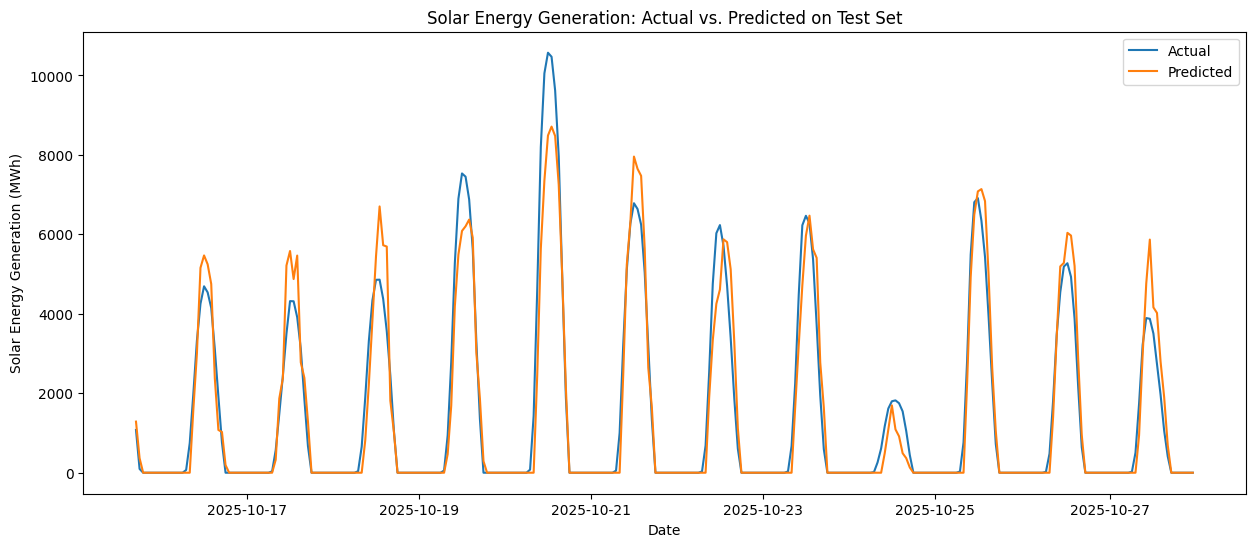

In [30]:
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_test['pred'], label='Predicted')
plt.title('Solar Energy Generation: Actual vs. Predicted on Test Set')
plt.xlabel('Date')
plt.ylabel('Solar Energy Generation (MWh)')
plt.legend()
plt.show()

In [31]:
pd.options.plotting.backend = "plotly"
y_pred_test.plot(title='Solar Energy Generation: Actual vs. Predicted on Test Set')


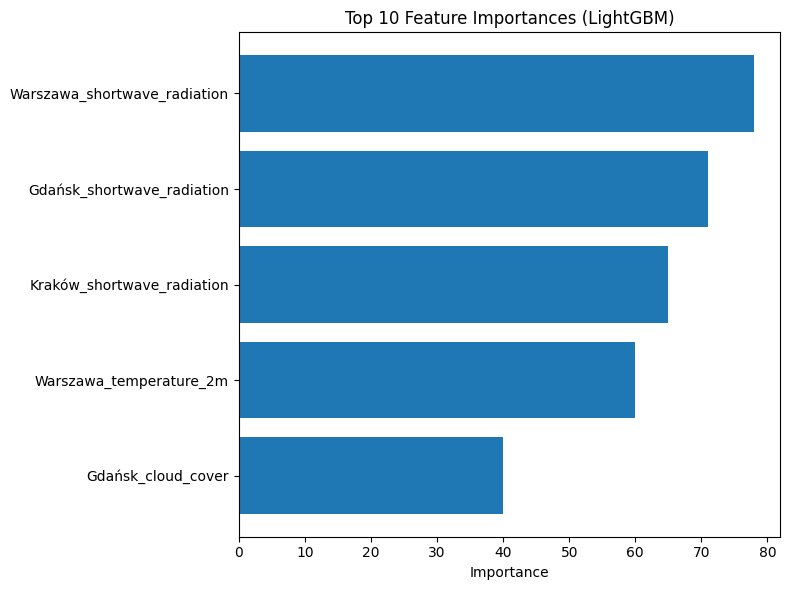

In [32]:
importance = best_model.feature_importances_
feature_names = best_model.feature_name_

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(fi['feature'], fi['importance'])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (LightGBM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Koszt Bilansowania

In [36]:
from google.colab import files


uploaded = files.upload()

Saving fixing_prices_2.csv to fixing_prices_2.csv


In [37]:
fixing_df = pd.read_csv('fixing_prices_2.csv')
fixing_df

,deliveryDatetimeUTC,price
0,2025-11-30 23:00:00.000000 UTC,444.00
1,2025-12-01 00:00:00.000000 UTC,461.74
2,2025-12-01 01:00:00.000000 UTC,448.00
3,2025-12-01 02:00:00.000000 UTC,446.00
4,2025-12-01 03:00:00.000000 UTC,425.17
...,...,...
7651,2025-04-30 06:00:00.000000 UTC,400.00
7652,2025-04-12 21:00:00.000000 UTC,470.00
7653,2025-04-15 19:00:00.000000 UTC,470.00
7654,2025-04-20 22:00:00.000000 UTC,470.00


In [38]:
fixing_df['datetimePL'] = pd.to_datetime(fixing_df['deliveryDatetimeUTC']).dt.tz_convert('Europe/Warsaw')
fixing_df = fixing_df.drop(['deliveryDatetimeUTC'], axis=1)
fixing_df.set_index('datetimePL', inplace=True)
fixing_df.sort_index()

,price
datetimePL,
2025-02-01 00:00:00+01:00,526.89
2025-02-01 01:00:00+01:00,515.00
2025-02-01 02:00:00+01:00,502.00
2025-02-01 03:00:00+01:00,500.01
2025-02-01 04:00:00+01:00,504.17
...,...
2025-12-16 19:00:00+01:00,690.00
2025-12-16 20:00:00+01:00,580.00
2025-12-16 21:00:00+01:00,494.00


### Cena rozliczeniowa PSE

In [39]:
from datetime import datetime, timedelta
import requests

url = "https://api.raporty.pse.pl/api/price-cost"

end_date = datetime.now()
start_date = end_date - timedelta(days=450)

filter_query = f"dtime_utc ge '{start_date.strftime('%Y-%m-%d')}' and dtime_utc le '{end_date.strftime('%Y-%m-%d')}'"

params = {"$filter": filter_query, "$orderby": "dtime_utc", "$first": 90000}

response = requests.get(url, params=params)

if response.status_code != 200:
    print("Error:", response.status_code, response.text)
else:
    data = response.json()

    df = pd.DataFrame(data["value"])

    columns_to_keep = ['cen_cost', 'dtime_utc']
    cen_roz_df = df[columns_to_keep].copy()
    cen_roz_df

In [40]:
cen_roz_df['datetimePL'] = pd.to_datetime(cen_roz_df['dtime_utc'], utc=True).dt.tz_convert('Europe/Warsaw') - pd.to_timedelta(15, unit='minutes')
cen_roz_df.drop(columns=['dtime_utc'], inplace=True)
cen_roz_df = cen_roz_df.set_index('datetimePL')
cen_roz_df.plot(y='cen_cost')

In [41]:
cen_roz_df_h = cen_roz_df.resample('h').mean()

In [42]:
prices_df = fixing_df.join(cen_roz_df_h, on='datetimePL')
prices_df.rename(columns={'cen_cost': 'rb_price'}, inplace=True)
prices_df

,price,rb_price
datetimePL,,
2025-12-01 00:00:00+01:00,444.00,597.9975
2025-12-01 01:00:00+01:00,461.74,615.2975
2025-12-01 02:00:00+01:00,448.00,592.0075
2025-12-01 03:00:00+01:00,446.00,234.3650
2025-12-01 04:00:00+01:00,425.17,342.4425
...,...,...
2025-04-30 08:00:00+02:00,400.00,218.1200
2025-04-12 23:00:00+02:00,470.00,NaN
2025-04-15 21:00:00+02:00,470.00,NaN


In [43]:
df_metric  = y_pred_test.join(prices_df).dropna()

In [44]:
df_metric.head()

,pred,true,price,rb_price
datetimePL,,,,
2025-10-15 17:00:00+02:00,1286.697138,1077.0,849.00,717.7125
2025-10-15 18:00:00+02:00,366.801024,96.0,1100.01,389.0925
2025-10-15 19:00:00+02:00,0.000000,0.0,1193.00,451.0550
2025-10-15 20:00:00+02:00,0.000000,0.0,759.00,417.1350
2025-10-15 21:00:00+02:00,0.000000,0.0,523.81,455.5825


In [45]:
df_metric['Balancing_Cost'] = (df_metric["pred"] - df_metric["true"]) * (df_metric['price'] - df_metric['rb_price'])

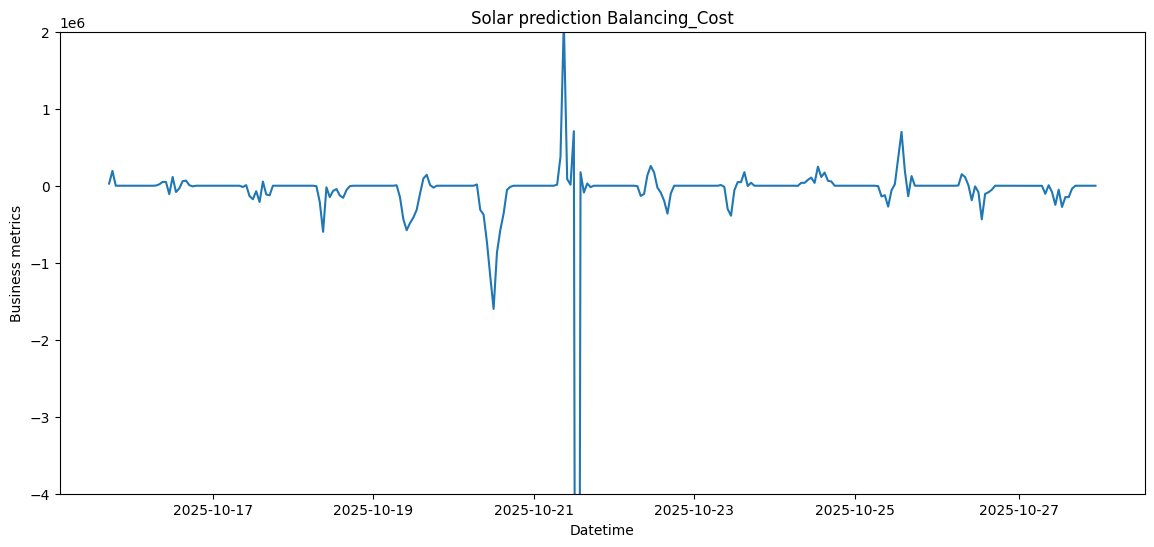

In [46]:
plt.figure(figsize=(14, 6))
plt.plot(df_metric.index, df_metric['Balancing_Cost'], label='Actual')
plt.title('Solar prediction Balancing_Cost')
plt.xlabel('Datetime')
plt.ylabel('Business metrics')
plt.ylim(-4000000, 2000000)
plt.show()

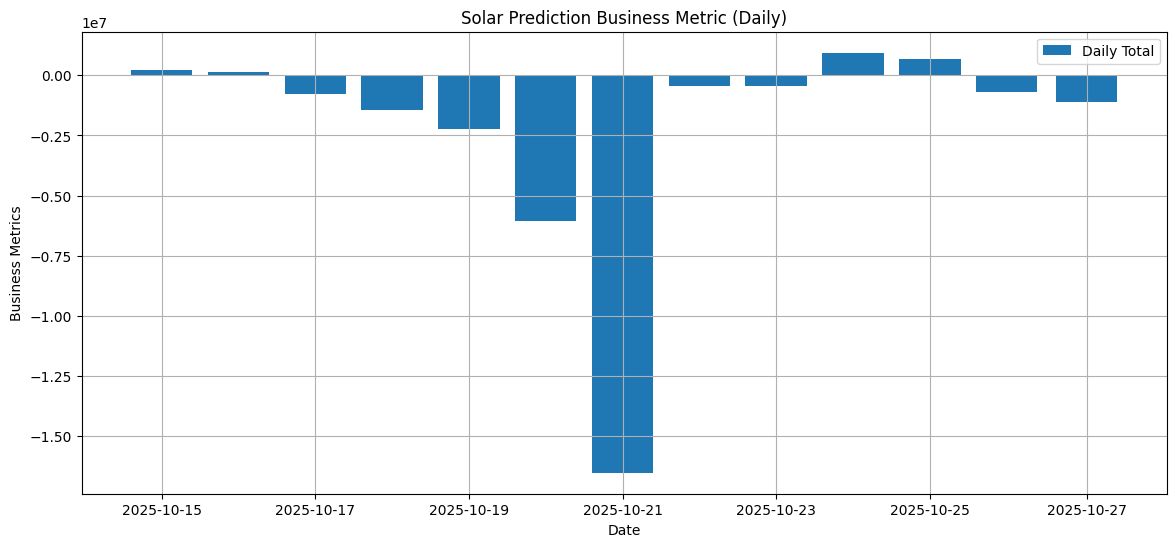

In [47]:
daily_df = df_metric['Balancing_Cost'].resample('D').sum()

plt.figure(figsize=(14, 6))
plt.bar(daily_df.index, daily_df, label='Daily Total')
plt.title('Solar Prediction Business Metric (Daily)')
plt.xlabel('Date')
plt.ylabel('Business Metrics')
plt.grid(True)
plt.legend()
plt.show()


In [48]:
print(f"Buisness metrics: {df_metric['Balancing_Cost'].sum() / df_metric['true'].sum()}")

Buisness metrics: -63.93647545124106


## Model predykcyjny energii wiatrowej

In [49]:
df = df_wind

In [50]:
df.columns

Index(['datetime_clean', 'Solar_Poland', 'Wind Onshore_Poland',
       'Gdańsk_cloud_cover', 'Kraków_cloud_cover', 'Warszawa_cloud_cover',
       'Gdańsk_shortwave_radiation', 'Kraków_shortwave_radiation',
       'Warszawa_shortwave_radiation', 'Gdańsk_temperature_2m',
       'Kraków_temperature_2m', 'Warszawa_temperature_2m',
       'Gdańsk_wind_speed_10m', 'Kraków_wind_speed_10m',
       'Warszawa_wind_speed_10m', 'hour_0', 'hour_1', 'hour_2', 'hour_3',
       'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10',
       'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16',
       'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22',
       'hour_23', 'Warszawa_shortwave_radiation_res3',
       'Kraków_shortwave_radiation_res3', 'Gdańsk_shortwave_radiation_res3',
       'Warszawa_wind_speed_10m_res3', 'Kraków_wind_speed_10m_res3',
       'Gdańsk_wind_speed_10m_res3', 'hour'],
      dtype='object')

In [51]:
target = ["Wind Onshore_Poland"]
features = ['Kraków_wind_speed_10m', 'Warszawa_temperature_2m', 'Warszawa_wind_speed_10m_res3', 'Kraków_wind_speed_10m_res3', 'Gdańsk_wind_speed_10m_res3']

In [52]:
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("Train size:", len(train))
print("Validation size:", len(val))
print("Test size:", len(test))

Train size: 1376
Validation size: 295
Test size: 296


In [56]:
X_train = train[features]
X_val   = val[features]
X_test  = test[features]

y_train = train[target]
y_val   = val[target]
y_test  = test[target]

In [55]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
                          greater_is_better=False)

model_lgb = LGBMRegressor(random_state=0)

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 6, 7]
}


tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=model_lgb,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train.values, y_train.values.ravel())


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 1376, number of used features: 5
[LightGBM] [Info] Start training from score 2115.119913
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=LGBMRegressor(random_state=0), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 6, 7],
                         'n_estimators': [50, 100, 200]},
             scoring=make_scorer(<lambda>, greater_is_better=False, response_method='predict'),
             verbose=2)

In [57]:
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200}
Best CV RMSE: 1177.2516790926807


In [58]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 1376, number of used features: 5
[LightGBM] [Info] Start training from score 2115.119913
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMRegressor(learning_rate=0.01, max_depth=6, n_estimators=200, random_state=0)

In [ ]:


y_pred_train = best_model.predict(X_train)
y_pred_train = pd.DataFrame({'pred':y_pred_train, 'true': y_train['Wind Onshore_Poland']}, index=X_train.index)

y_pred_val = best_model.predict(X_val)
y_pred_val = pd.DataFrame({'pred':y_pred_val, 'true': y_val['Wind Onshore_Poland']}, index=X_val.index)

y_pred_test = best_model.predict(X_test)
y_pred_test = pd.DataFrame({'pred':y_pred_test, 'true': y_test['Wind Onshore_Poland']}, index=X_test.index)


mse = mean_squared_error(y_pred_train['pred'], y_pred_train['true'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_pred_train['pred'], y_pred_train['true'])
print("Train set Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

mse = mean_squared_error(y_pred_val['pred'], y_pred_val['true'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_pred_val['pred'], y_pred_val['true'])
print("\nVal Set Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

mse = mean_squared_error(y_pred_test['pred'], y_pred_test['true'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_pred_test['pred'], y_pred_test['true'])
print("\nTest Set Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Train set Evaluation:
Mean Squared Error (MSE): 900709.2459
Root Mean Squared Error (RMSE): 949.0570
Mean Absolute Error (MAE): 752.1229

Val Set Evaluation:
Mean Squared Error (MSE): 947244.4191
Root Mean Squared Error (RMSE): 973.2648
Mean Absolute Error (MAE): 798.1938

Test Set Evaluation:
Mean Squared Error (MSE): 2123779.9120
Root Mean Squared Error (RMSE): 1457.3194
Mean Absolute Error (MAE): 1181.8900


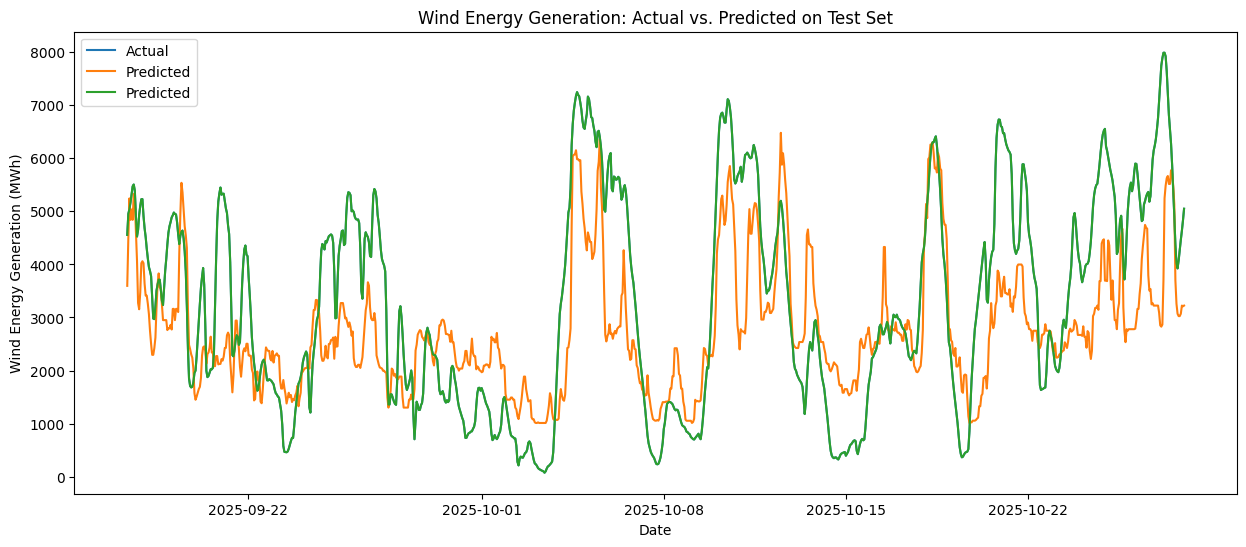

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_test, label='Predicted')
plt.title('Wind Energy Generation: Actual vs. Predicted on Test Set')
plt.xlabel('Date')
plt.ylabel('Wind Energy Generation (MWh)')
plt.legend()
plt.show()

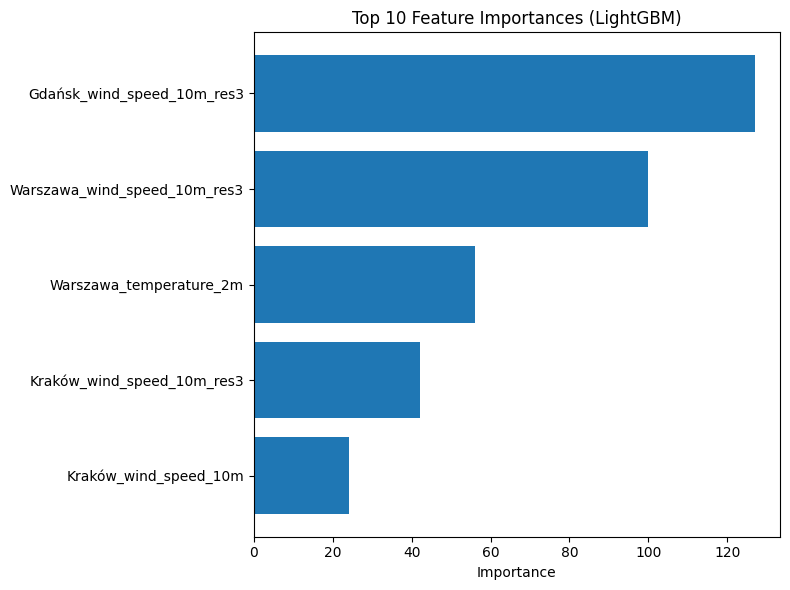

In [ ]:
importance = best_model.feature_importances_
feature_names = best_model.feature_name_

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(fi['feature'], fi['importance'])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (LightGBM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Koszt Bilansowania

In [ ]:
df_metric  = y_pred_test.join(prices_df).dropna()

In [ ]:
df_metric

,pred,true,price,rb_price
datetimePL,,,,
2025-09-17 09:00:00+02:00,3595.760569,4556.0000,431.32,442.0525
2025-09-17 10:00:00+02:00,4487.306767,4952.0000,323.58,510.1600
2025-09-17 11:00:00+02:00,5243.508036,5040.0000,205.00,554.7800
2025-09-17 12:00:00+02:00,4839.290109,5166.0000,110.76,513.6250
2025-09-17 13:00:00+02:00,5034.970583,5326.0000,90.11,423.5025
...,...,...,...,...
2025-10-27 19:00:00+01:00,3025.762644,4271.9315,657.70,632.7300
2025-10-27 20:00:00+01:00,3069.956520,4461.0195,461.00,602.9050
2025-10-27 21:00:00+01:00,3223.918955,4634.9745,393.93,504.9250


In [ ]:
df_metric['Balancing_Cost'] = (df_metric["true"] - df_metric["pred"]) * (df_metric['rb_price'] - df_metric['price'])

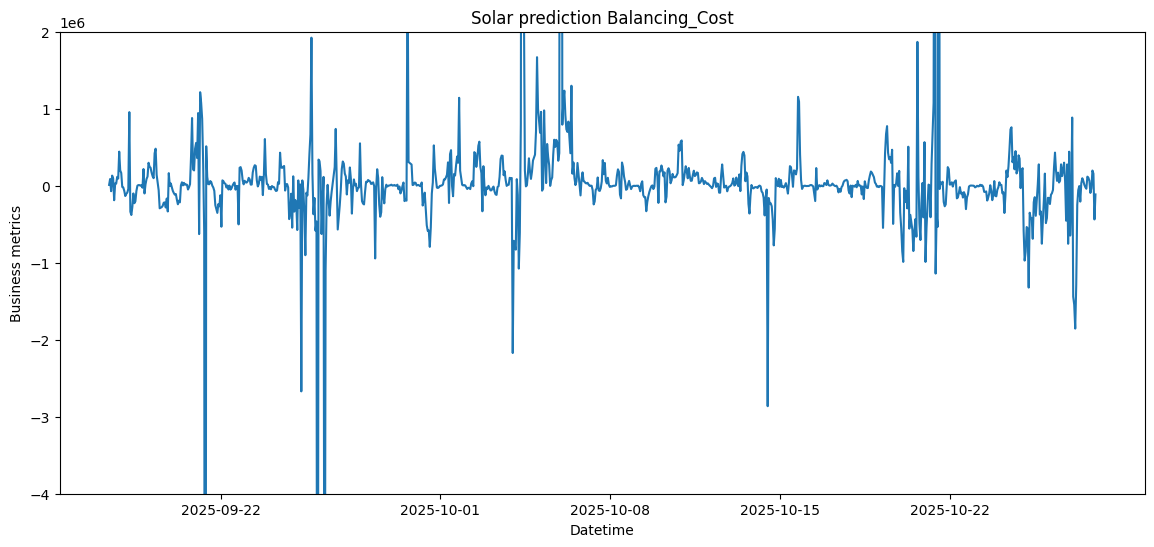

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df_metric.index, df_metric['Balancing_Cost'], label='Actual')
plt.title('Solar prediction Balancing_Cost')
plt.xlabel('Datetime')
plt.ylabel('Business metrics')
plt.ylim(-4000000, 2000000)
plt.show()

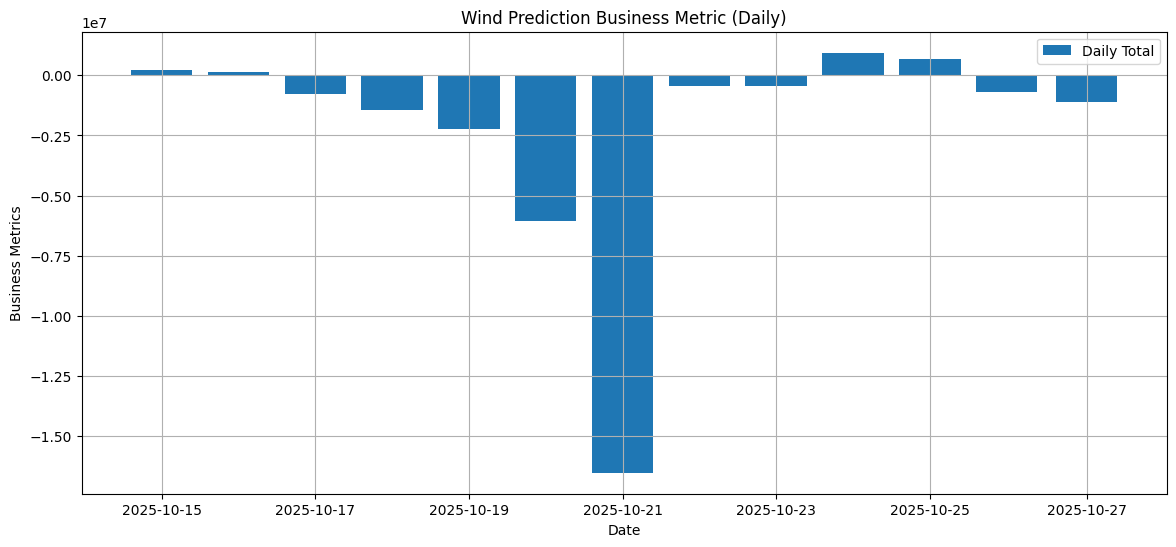

In [59]:
daily_df = df_metric['Balancing_Cost'].resample('D').sum()

plt.figure(figsize=(14, 6))
plt.bar(daily_df.index, daily_df, label='Daily Total')
plt.title('Wind Prediction Business Metric (Daily)')
plt.xlabel('Date')
plt.ylabel('Business Metrics')
plt.grid(True)
plt.legend()
plt.show()


In [60]:
df_metric['Balancing_Cost'].describe()

,Balancing_Cost
count,2.960000e+02
mean,-9.387830e+04
std,1.180608e+06
min,-1.996904e+07
25%,-5.416326e+03
50%,-0.000000e+00
75%,0.000000e+00
max,2.140280e+06


In [61]:
print(f"Buisness metrics: {df_metric['Balancing_Cost'].sum() / df_metric['true'].sum()}")

Buisness metrics: -63.93647545124106
